# Omega Notebook

本 notebook 为本次作业的交付文件，覆盖贷款数据清洗、KNN 补值、背包建模求解与结果可视化。

本 notebook 默认自动运行内置演示数据，适合课堂/答辩现场直接展示完整流程。

默认演示内容：
- 使用 `base_records + extra_dirty_records` 作为内置样本
- 自动展示原始样本、清洗结果、KNN 补值统计、补值记录和背包摘要
- 背包算法保持不变，仅用于展示最终摘要

如需扩展测试，也可以手动调用 `run_import_test(...)` / `run_source_knn_test(...)`。

示例：
```python
result = run_import_test(
    dataset_path="/Users/schelling/Desktop/public_150k_plus_240930.csv",
    source_name="sba_public_demo",
    nrows=20000,
    show_plots=False,
)

knn_result = run_source_knn_test(
    load_imported_dataset("/Users/schelling/Desktop/public_150k_plus_240930.csv", nrows=20000),
    source_name="sba_public_demo",
    n_neighbors=3,
)
```


In [7]:
from __future__ import annotations

import copy
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

for font_name in ['PingFang HK', 'Hiragino Sans GB', 'Heiti TC', 'STHeiti', 'Arial Unicode MS']:
    if font_name in {font.name for font in font_manager.fontManager.ttflist}:
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
plt.rcParams['axes.unicode_minus'] = False

capacity = 1_000_000.0
n_neighbors = 3
NOTEBOOK_HOME = (Path.cwd() / 'projectA').resolve() if (Path.cwd() / 'projectA').exists() else Path.cwd().resolve()
DATA_SOURCE_MODE = 'builtin'
DATASET_PATH = None
DATASET_SOURCE_NAME = 'omega_demo'
NROWS = None


In [8]:
MISSING_COMPARE_COLS = ['credit_score', 'debt_to_income_ratio', 'property_value']
DEFAULT_CAPACITY = 1_000_000.0
KEY_COL = 'loan_id'

base_records = [
    {
        'loan_id': 'HL0001',
        'borrower_name': '张三',
        'property_type': '住宅',
        'property_value': 1600000,
        'loan_amount': 800000,
        'expected_return_rate': 0.052,
        'credit_score': 735,
        'debt_to_income_ratio': 0.32,
        'annual_income': 220000,
        'ltv_ratio': 0.50,
        'overdue_count': 0,
        'employment_years': 6,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0002',
        'borrower_name': '李四',
        'property_type': '公寓',
        'property_value': 1200000,
        'loan_amount': 720000,
        'expected_return_rate': 0.058,
        'credit_score': 695,
        'debt_to_income_ratio': 0.41,
        'annual_income': 180000,
        'ltv_ratio': 0.60,
        'overdue_count': 1,
        'employment_years': 4,
        'risk_level': '中',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0003',
        'borrower_name': '王五',
        'property_type': '商铺',
        'property_value': 2400000,
        'loan_amount': 1500000,
        'expected_return_rate': 0.066,
        'credit_score': 710,
        'debt_to_income_ratio': 0.38,
        'annual_income': 300000,
        'ltv_ratio': 0.625,
        'overdue_count': 0,
        'employment_years': 8,
        'risk_level': '中风险',
        'application_status': '正常',
    },
]
#脏数据表
extra_dirty_records = [
    {
        'loan_id': None,
        'borrower_name': '林婉清',
        'property_type': '住宅',
        'property_value': '待定',
        'loan_amount': '待定',
        'expected_return_rate': '?',
        'credit_score': 'unknown',
        'debt_to_income_ratio': ' ',
        'annual_income': 'abc',
        'ltv_ratio': '?',
        'overdue_count': 1,
        'employment_years': 5,
        'risk_level': '中风险',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0041',
        'borrower_name': '陈浩然',
        'property_type': '公寓',
        'property_value': '120万',
        'loan_amount': '',
        'expected_return_rate': '待定',
        'credit_score': None,
        'debt_to_income_ratio': '?',
        'annual_income': 'unknown',
        'ltv_ratio': '?',
        'overdue_count': 0,
        'employment_years': 2,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': ' ',
        'borrower_name': '郑雅婷',
        'property_type': '住宅',
        'property_value': '150万',
        'loan_amount': '￥650,000',
        'expected_return_rate': '',
        'credit_score': 'abc',
        'debt_to_income_ratio': 0.43,
        'annual_income': None,
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 4,
        'risk_level': '中',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0043',
        'borrower_name': '马嘉诚',
        'property_type': '商铺',
        'property_value': '260万',
        'loan_amount': '?',
        'expected_return_rate': 0.066,
        'credit_score': 718,
        'debt_to_income_ratio': '待定',
        'annual_income': ' ',
        'ltv_ratio': None,
        'overdue_count': 1,
        'employment_years': 8,
        'risk_level': '高风险',
        'application_status': '拒绝',
    },
    {
        'loan_id': 'HL0044',
        'borrower_name': '许诺',
        'property_type': '住宅',
        'property_value': '100万',
        'loan_amount': '30万',
        'expected_return_rate': '6.2%',
        'credit_score': '?',
        'debt_to_income_ratio': None,
        'annual_income': '待定',
        'ltv_ratio': None,
        'overdue_count': 2,
        'employment_years': 3,
        'risk_level': '高',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0045',
        'borrower_name': '何思远',
        'property_type': '住宅',
        'property_value': '180万',
        'loan_amount': '90万',
        'expected_return_rate': '5.8%',
        'credit_score': 'unknown',
        'debt_to_income_ratio': '?',
        'annual_income': 220000,
        'ltv_ratio': None,
        'overdue_count': 1,
        'employment_years': 5,
        'risk_level': '中风险',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0045',
        'borrower_name': '何思远',
        'property_type': '住宅',
        'property_value': '180万',
        'loan_amount': '90万',
        'expected_return_rate': '5.8%',
        'credit_score': 'unknown',
        'debt_to_income_ratio': '?',
        'annual_income': 220000,
        'ltv_ratio': None,
        'overdue_count': 1,
        'employment_years': 5,
        'risk_level': '中风险',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0046',
        'borrower_name': '梁雨薇',
        'property_type': '公寓',
        'property_value': '220万',
        'loan_amount': '80万',
        'expected_return_rate': '5.6%',
        'credit_score': 702,
        'debt_to_income_ratio': None,
        'annual_income': '26万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 6,
        'risk_level': '中',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0047',
        'borrower_name': '韩子墨',
        'property_type': '住宅',
        'property_value': None,
        'loan_amount': '￥720,000',
        'expected_return_rate': 0.061,
        'credit_score': 688,
        'debt_to_income_ratio': 0.47,
        'annual_income': '21万',
        'ltv_ratio': None,
        'overdue_count': 1,
        'employment_years': 4,
        'risk_level': '中风险',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0048',
        'borrower_name': '秦沐阳',
        'property_type': '商铺',
        'property_value': '310万',
        'loan_amount': '120万',
        'expected_return_rate': '待定',
        'credit_score': 724,
        'debt_to_income_ratio': 0.35,
        'annual_income': '38万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 9,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0049',
        'borrower_name': '顾晨曦',
        'property_type': '住宅',
        'property_value': '160万',
        'loan_amount': '0',
        'expected_return_rate': '5.3%',
        'credit_score': 675,
        'debt_to_income_ratio': 0.52,
        'annual_income': '18万',
        'ltv_ratio': None,
        'overdue_count': 2,
        'employment_years': 3,
        'risk_level': '高',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0050',
        'borrower_name': '唐若溪',
        'property_type': '公寓',
        'property_value': '190万',
        'loan_amount': '70万',
        'expected_return_rate': '5.9%',
        'credit_score': None,
        'debt_to_income_ratio': '待定',
        'annual_income': '24万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 7,
        'risk_level': '中',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0061',
        'borrower_name': '沈星河',
        'property_type': '住宅',
        'property_value': '80万',
        'loan_amount': '5.2万',
        'expected_return_rate': '6.8%',
        'credit_score': None,
        'debt_to_income_ratio': '待定',
        'annual_income': '31万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 5,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0062',
        'borrower_name': '陆知远',
        'property_type': '公寓',
        'property_value': '82万',
        'loan_amount': '5.8万',
        'expected_return_rate': '6.8%',
        'credit_score': 732,
        'debt_to_income_ratio': 0.29,
        'annual_income': '32万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 6,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0063',
        'borrower_name': '叶清欢',
        'property_type': '住宅',
        'property_value': None,
        'loan_amount': '6.3万',
        'expected_return_rate': '6.8%',
        'credit_score': 735,
        'debt_to_income_ratio': 0.31,
        'annual_income': '33万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 7,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0064',
        'borrower_name': '苏明澈',
        'property_type': '公寓',
        'property_value': '85万',
        'loan_amount': '6.9万',
        'expected_return_rate': '6.8%',
        'credit_score': None,
        'debt_to_income_ratio': 0.32,
        'annual_income': '34万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 5,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0065',
        'borrower_name': '白景行',
        'property_type': '住宅',
        'property_value': '88万',
        'loan_amount': '7.4万',
        'expected_return_rate': '6.8%',
        'credit_score': 736,
        'debt_to_income_ratio': '待定',
        'annual_income': '35万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 8,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0066',
        'borrower_name': '夏若宁',
        'property_type': '公寓',
        'property_value': '90万',
        'loan_amount': '8.0万',
        'expected_return_rate': '6.8%',
        'credit_score': 731,
        'debt_to_income_ratio': 0.28,
        'annual_income': '36万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 6,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0067',
        'borrower_name': '顾言川',
        'property_type': '住宅',
        'property_value': None,
        'loan_amount': '8.5万',
        'expected_return_rate': '6.8%',
        'credit_score': None,
        'debt_to_income_ratio': 0.30,
        'annual_income': '31万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 7,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0068',
        'borrower_name': '乔安然',
        'property_type': '公寓',
        'property_value': '86万',
        'loan_amount': '9.1万',
        'expected_return_rate': '6.8%',
        'credit_score': 734,
        'debt_to_income_ratio': '待定',
        'annual_income': '33万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 5,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0069',
        'borrower_name': '程予安',
        'property_type': '住宅',
        'property_value': '84万',
        'loan_amount': '9.6万',
        'expected_return_rate': '6.8%',
        'credit_score': 733,
        'debt_to_income_ratio': 0.33,
        'annual_income': '34万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 8,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0070',
        'borrower_name': '钟沐晨',
        'property_type': '公寓',
        'property_value': '89万',
        'loan_amount': '10.2万',
        'expected_return_rate': '6.8%',
        'credit_score': None,
        'debt_to_income_ratio': 0.29,
        'annual_income': '35万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 6,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0071',
        'borrower_name': '姜听澜',
        'property_type': '住宅',
        'property_value': None,
        'loan_amount': '10.8万',
        'expected_return_rate': '6.8%',
        'credit_score': 737,
        'debt_to_income_ratio': '待定',
        'annual_income': '36万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 7,
        'risk_level': '低',
        'application_status': '正常',
    },
    {
        'loan_id': 'HL0072',
        'borrower_name': '谢云舟',
        'property_type': '公寓',
        'property_value': '92万',
        'loan_amount': '11.4万',
        'expected_return_rate': '6.8%',
        'credit_score': 738,
        'debt_to_income_ratio': 0.31,
        'annual_income': '32万',
        'ltv_ratio': None,
        'overdue_count': 0,
        'employment_years': 8,
        'risk_level': '低',
        'application_status': '正常',
    },
]

REQUIRED_CLEAN_COLUMNS = ['loan_id', 'loan_amount', 'expected_return_rate', 'risk_level', 'application_status']
MISSING_TEXT_VALUES = {'', '?', 'unknown', 'none', 'null', 'nan', '待定'}
RISK_LEVEL_MAP = {
    '低': '低', '低风险': '低', 'low': '低', 'lowrisk': '低',
    '中': '中', '中风险': '中', 'medium': '中', 'mediumrisk': '中',
    '高': '高', '高风险': '高', 'high': '高', 'highrisk': '高',
}
APPLICATION_STATUS_MAP = {
    '正常': '正常',
    'active': '正常',
    '待审': '正常',
    '审批中': '正常',
    '已提交': '正常',
    '在贷': '正常',

    '拒绝': '拒绝',
    'rejected': '拒绝',
    '撤回': '撤回',
    'withdrawn': '撤回',

    '逾期': '逾期',
    'overdue': '逾期',

    '结清': '结清',
    '已结清': '结清',
    'closed': '结清',
}
DEFAULT_TARGET_COLS = ['credit_score', 'debt_to_income_ratio', 'property_value']
DEFAULT_FEATURE_COLS = [
    'loan_amount',
    'expected_return_rate',
    'property_value',
    'ltv_ratio',
    'annual_income',
    'overdue_count',
    'employment_years',
    'credit_score',
    'debt_to_income_ratio',
]
NUMERIC_DEMO_COLUMNS = ['property_value', 'credit_score', 'debt_to_income_ratio', 'annual_income', 'ltv_ratio', 'overdue_count', 'employment_years']
REQUIRED_INTERFACE_COLUMNS = ['loan_id', 'borrower_name', 'loan_amount', 'expected_return_rate', 'risk_level']
RISK_ADJUSTMENT_MAP = {
    '低': 1.0, '低风险': 1.0, 'low': 1.0, 'lowrisk': 1.0,
    '中': 0.8, '中风险': 0.8, 'medium': 0.8, 'mediumrisk': 0.8,
    '高': 0.6, '高风险': 0.6, 'high': 0.6, 'highrisk': 0.6,
}
FORMAL_APPLICATION_REQUIRED_COLUMNS = [
    'company_id',
    'industry',
    'years_in_business',
    'annual_revenue_million',
    'liability_ratio',
    'loan_amount_million',
    'credit_score',
    'has_overdue',
    'approval_status',
]
REQUIRED_ITEM_COLUMNS = ['item_id', 'w', 'v']
DISPLAY_NAME_MAP = {
    'loan_id': '贷款编号',
    'borrower_name': '借款人姓名',
    'property_type': '房产类型',
    'property_value': '房产评估价值',
    'loan_amount': '贷款金额',
    'expected_return_rate': '预期收益率',
    'credit_score': '信用评分',
    'debt_to_income_ratio': '负债收入比',
    'annual_income': '年收入',
    'ltv_ratio': '贷款价值比',
    'overdue_count': '历史逾期次数',
    'employment_years': '工作年限',
    'risk_level': '风险等级',
    'application_status': '申请状态',
    'item_id': '项目编号',
    'w': '当前重量',
    'v': '当前收益',
    'path_node': '路径节点',
    'cum_w': '累计重量',
    'cum_v': '累计收益',
}
CANONICAL_COLUMNS = [
    'loan_id',
    'borrower_name',
    'property_type',
    'property_value',
    'loan_amount',
    'expected_return_rate',
    'credit_score',
    'debt_to_income_ratio',
    'annual_income',
    'ltv_ratio',
    'overdue_count',
    'employment_years',
    'risk_level',
    'application_status',
]


In [9]:
def _ensure_dataframe(df: pd.DataFrame, name: str) -> None:
    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'{name} must be a pandas DataFrame')


def _ensure_columns(df: pd.DataFrame, columns: Sequence[str], name: str) -> list[str]:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise ValueError(f'{name} is missing required columns: {missing}')
    return list(columns)


def _ensure_unique_key(df: pd.DataFrame, key_col: str, name: str) -> None:
    if not df[key_col].is_unique:
        raise ValueError(f'{name}.{key_col} must be unique for row-level comparison')


def _ensure_same_key_set(before_df: pd.DataFrame, after_df: pd.DataFrame, key_col: str) -> pd.DataFrame:
    before_keys = before_df[key_col].tolist()
    after_keys = after_df[key_col].tolist()
    if set(before_keys) != set(after_keys):
        raise ValueError('before_df and after_df must contain the same key set for row comparison')
    if before_keys == after_keys:
        return after_df
    return after_df.set_index(key_col).loc[before_keys].reset_index()


def _print_title(title: str | None) -> None:
    if title:
        print(f'\n=== {title} ===')


def _print_frame(df: pd.DataFrame) -> None:
    with pd.option_context('display.max_columns', None, 'display.width', 1200, 'display.max_colwidth', 120):
        print(df)


def _display_name(name: object) -> object:
    if not isinstance(name, str):
        return name
    if name.startswith('before_'):
        base_name = name[len('before_'):]
        return f"补值前_{DISPLAY_NAME_MAP.get(base_name, base_name)}"
    if name.startswith('after_'):
        base_name = name[len('after_'):]
        return f"补值后_{DISPLAY_NAME_MAP.get(base_name, base_name)}"
    return DISPLAY_NAME_MAP.get(name, name)


def _localize_display_df(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=_display_name)


def _ensure_source_columns(df: pd.DataFrame, columns: Sequence[str], source_name: str) -> None:
    missing_columns = [column for column in columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f'{source_name} is missing required source columns: {missing_columns}')


def _ensure_canonical_columns(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    for column in CANONICAL_COLUMNS:
        if column not in result_df.columns:
            result_df[column] = pd.NA
    return result_df.loc[:, CANONICAL_COLUMNS]


def _coerce_optional_float(value: object, multiplier: float = 1.0) -> object:
    if pd.isna(value) or isinstance(value, bool):
        return pd.NA
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped or stripped.casefold() in {token.casefold() for token in MISSING_TEXT_VALUES}:
            return pd.NA
        try:
            return float(stripped) * multiplier
        except ValueError:
            return pd.NA
    return float(value) * multiplier


def _map_alt_risk_score(value: object) -> object:
    numeric_value = _coerce_optional_float(value)
    if pd.isna(numeric_value):
        return pd.NA
    if not float(numeric_value).is_integer():
        raise ValueError('risk_score must be a whole number')
    return {1: '低', 2: '中', 3: '高'}.get(int(numeric_value), pd.NA)


def _map_alt_status_flag(value: object) -> object:
    if pd.isna(value):
        return pd.NA
    normalized = str(value).strip().casefold()
    return {'active': '正常', 'inactive': '注销', 'closed': '注销'}.get(normalized, pd.NA)


def _map_sba_business_age(value: object) -> object:
    if pd.isna(value):
        return pd.NA
    normalized = str(value).strip().casefold()
    if normalized == 'existing or more than 2 years old':
        return 3
    if normalized == 'new business or 2 years or less':
        return 1
    if normalized == 'startup, loan funds will open business':
        return 0
    return pd.NA


def _derive_sba_risk_level(record: dict[str, object]) -> object:
    loan_status = record.get('LoanStatus')
    if pd.isna(loan_status):
        return '中'
    normalized = str(loan_status).strip().casefold()
    if normalized in {'paid in full', 'exemption 4'}:
        return '低'
    if normalized in {'charge off', 'cancelled'}:
        return '高'
    return '中'


def _derive_sba_operating_status(record: dict[str, object]) -> object:
    loan_status = record.get('LoanStatus')
    if pd.isna(loan_status):
        return '正常'
    normalized = str(loan_status).strip().casefold()
    if normalized in {'charge off', 'cancelled'}:
        return '注销'
    return '正常'


def _derive_risk_level_from_formal_fields(record: dict[str, object]) -> object:
    credit_score = _coerce_optional_float(record.get('credit_score'))
    liability_ratio = _coerce_optional_float(record.get('liability_ratio'))
    has_overdue = _coerce_optional_float(record.get('has_overdue'))
    if not pd.isna(has_overdue) and int(has_overdue) == 1:
        return '高'
    if not pd.isna(credit_score) and credit_score >= 710 and (pd.isna(liability_ratio) or liability_ratio <= 0.45):
        return '低'
    if not pd.isna(credit_score) and credit_score < 680:
        return '高'
    if not pd.isna(liability_ratio) and liability_ratio >= 0.6:
        return '高'
    return '中'


def _derive_operating_status_from_formal_fields(record: dict[str, object]) -> object:
    approval_status = record.get('approval_status')
    if pd.isna(approval_status):
        return pd.NA
    normalized = str(approval_status).strip().casefold()
    if normalized in {'approved', 'review'}:
        return '正常'
    if normalized in {'rejected', 'withdrawn'}:
        return '注销'
    return pd.NA


def _adapt_omega_demo_source(raw_records: list[dict[str, object]]) -> pd.DataFrame:
    return _ensure_canonical_columns(pd.DataFrame(copy.deepcopy(raw_records)))


def _adapt_formal_application_demo(raw_records: list[dict[str, object]]) -> pd.DataFrame:
    raw_df = pd.DataFrame(copy.deepcopy(raw_records))
    _ensure_source_columns(raw_df, FORMAL_APPLICATION_REQUIRED_COLUMNS, 'formal_application_demo')
    adapted_records = []
    for record in raw_df.to_dict('records'):
        overdue_value = _coerce_optional_float(record.get('has_overdue'))
        adapted_records.append({
            'loan_id': record.get('company_id'),
            'enterprise_name': record.get('company_id'),
            'loan_amount': _coerce_optional_float(record.get('loan_amount_million'), multiplier=1000000.0),
            'expected_return_rate': pd.NA,
            'credit_score': record.get('credit_score'),
            'debt_ratio': _coerce_optional_float(record.get('liability_ratio')),
            'annual_revenue': _coerce_optional_float(record.get('annual_revenue_million'), multiplier=1000000.0),
            'default_count': 0 if pd.isna(overdue_value) else int(overdue_value),
            'operation_years': record.get('years_in_business'),
            'industry_type': record.get('industry'),
            'risk_level': _derive_risk_level_from_formal_fields(record),
            'operating_status': _derive_operating_status_from_formal_fields(record),
        })
    return _ensure_canonical_columns(pd.DataFrame(adapted_records))


def _adapt_alt_source_demo(raw_records: list[dict[str, object]]) -> pd.DataFrame:
    adapted_records = []
    for record in copy.deepcopy(raw_records):
        adapted_records.append({
            'loan_id': record.get('biz_id'),
            'enterprise_name': record.get('company'),
            'loan_amount': _coerce_optional_float(record.get('amount_wan'), multiplier=10000.0),
            'expected_return_rate': _coerce_optional_float(record.get('yield_pct'), multiplier=0.01),
            'credit_score': record.get('credit'),
            'debt_ratio': _coerce_optional_float(record.get('debt_pct'), multiplier=0.01),
            'annual_revenue': _coerce_optional_float(record.get('monthly_revenue_wan'), multiplier=120000.0),
            'default_count': record.get('defaults'),
            'operation_years': record.get('years_running'),
            'industry_type': record.get('sector'),
            'risk_level': _map_alt_risk_score(record.get('risk_score')),
            'operating_status': _map_alt_status_flag(record.get('status_flag')),
        })
    return _ensure_canonical_columns(pd.DataFrame(adapted_records))


def _adapt_sba_public_demo(raw_records: list[dict[str, object]]) -> pd.DataFrame:
    adapted_records = []
    for record in copy.deepcopy(raw_records):
        adapted_records.append({
            'loan_id': record.get('LoanNumber'),
            'enterprise_name': record.get('BorrowerName'),
            'loan_amount': _coerce_optional_float(record.get('CurrentApprovalAmount')),
            'expected_return_rate': pd.NA,
            'credit_score': pd.NA,
            'debt_ratio': pd.NA,
            'annual_revenue': pd.NA,
            'default_count': 0,
            'operation_years': _map_sba_business_age(record.get('BusinessAgeDescription')),
            'industry_type': record.get('NAICSCode'),
            'risk_level': _derive_sba_risk_level(record),
            'operating_status': _derive_sba_operating_status(record),
        })
    return _ensure_canonical_columns(pd.DataFrame(adapted_records))


SOURCE_ADAPTERS = {
    'omega_demo': _adapt_omega_demo_source,
    'formal_application_demo': _adapt_formal_application_demo,
    'alt_source_demo': _adapt_alt_source_demo,
    'sba_public_demo': _adapt_sba_public_demo,
}


def adapt_source_data(raw_records: list[dict[str, object]], source_name: str = 'omega_demo') -> pd.DataFrame:
    if source_name not in SOURCE_ADAPTERS:
        raise ValueError(f'Unsupported source_name: {source_name}')
    return SOURCE_ADAPTERS[source_name](raw_records)


def _build_adapter_debug(raw_records: list[dict[str, object]], adapted_df: pd.DataFrame, source_name: str) -> dict[str, object]:
    raw_df = pd.DataFrame(raw_records)
    return {
        'source_name': source_name,
        'input_columns': raw_df.columns.tolist(),
        'output_columns': adapted_df.columns.tolist(),
        'row_count_before': len(raw_df),
        'row_count_after': len(adapted_df),
    }


def _resolve_dataset_path(dataset_path: str) -> Path:
    dataset_name = Path(dataset_path).name
    candidates = [Path(dataset_path), NOTEBOOK_HOME / dataset_name, NOTEBOOK_HOME / 'projectA' / dataset_name]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(f'Dataset file not found: {dataset_path}')


def load_imported_dataset(dataset_path: str, file_type: str = 'csv', nrows: int | None = None) -> list[dict[str, object]]:
    resolved_path = _resolve_dataset_path(dataset_path)
    if file_type != 'csv':
        raise ValueError(f'Unsupported file_type: {file_type}')
    for encoding in ('utf-8', 'utf-8-sig', 'iso-8859-1'):
        try:
            return pd.read_csv(resolved_path, encoding=encoding, nrows=nrows, low_memory=False).to_dict('records')
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('csv', b'', 0, 1, f'Unable to decode dataset: {resolved_path}')


def load_source_records(data_source_mode: str = 'builtin', dataset_path: str | None = None, source_name: str = 'omega_demo', nrows: int | None = None) -> tuple[list[dict[str, object]], str]:
    if data_source_mode == 'builtin':
        return copy.deepcopy(extra_dirty_records), source_name
    if data_source_mode == 'csv':
        if not dataset_path:
            raise ValueError('dataset_path must be provided for csv mode')
        return load_imported_dataset(dataset_path, nrows=nrows), source_name
    raise ValueError(f'Unsupported data_source_mode: {data_source_mode}')


def build_source_knn_test_df(raw_records: list[dict[str, object]], source_name: str) -> pd.DataFrame:
    if source_name != 'sba_public_demo':
        raise ValueError(f'Unsupported source_name for KNN smoke test: {source_name}')
    rows = []
    for record in copy.deepcopy(raw_records):
        rows.append({
            'record_id': record.get('LoanNumber'),
            'term_months': _coerce_optional_float(record.get('Term')),
            'guaranty_pct': _coerce_optional_float(record.get('SBAGuarantyPercentage')),
            'initial_approval_amount': _coerce_optional_float(record.get('InitialApprovalAmount')),
            'current_approval_amount': _coerce_optional_float(record.get('CurrentApprovalAmount')),
            'undisbursed_amount': _coerce_optional_float(record.get('UndisbursedAmount')),
            'jobs_reported': _coerce_optional_float(record.get('JobsReported')),
            'forgiveness_amount': _coerce_optional_float(record.get('ForgivenessAmount')),
            'utilities_proceed': _coerce_optional_float(record.get('UTILITIES_PROCEED')),
            'payroll_proceed': _coerce_optional_float(record.get('PAYROLL_PROCEED')),
            'rent_proceed': _coerce_optional_float(record.get('RENT_PROCEED')),
        })
    return pd.DataFrame(rows)


def run_source_knn_test(raw_records: list[dict[str, object]], source_name: str, n_neighbors: int = 3) -> dict[str, object]:
    df_knn_input = build_source_knn_test_df(raw_records, source_name=source_name)
    target_cols = ['forgiveness_amount', 'utilities_proceed', 'rent_proceed']
    feature_cols = [
        'term_months',
        'guaranty_pct',
        'initial_approval_amount',
        'current_approval_amount',
        'undisbursed_amount',
        'jobs_reported',
        'forgiveness_amount',
        'utilities_proceed',
        'payroll_proceed',
        'rent_proceed',
    ]
    missing_before = df_knn_input[target_cols].isna().sum()
    df_knn_imputed = impute_missing_values(df_knn_input, n_neighbors=n_neighbors, target_cols=target_cols, feature_cols=feature_cols)
    missing_after = df_knn_imputed[target_cols].isna().sum()
    return {
        'df_knn_input': df_knn_input,
        'df_knn_imputed': df_knn_imputed,
        'target_cols': target_cols,
        'feature_cols': feature_cols,
        'missing_before': missing_before,
        'missing_after': missing_after,
    }


def run_import_test(dataset_path: str, source_name: str, nrows: int | None = None, show_plots: bool = False) -> dict[str, object]:
    raw_records = load_imported_dataset(dataset_path, nrows=nrows)
    return run_pipeline(show_plots=show_plots, raw_records=raw_records, source_name=source_name)


def _normalize_missing_token(value: object) -> object:
    if pd.isna(value):
        return pd.NA
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.casefold() in {token.casefold() for token in MISSING_TEXT_VALUES}:
            return pd.NA
        return stripped
    return value


def _normalize_text_key(value: object) -> object:
    if pd.isna(value):
        return pd.NA
    normalized = re.sub(r'[\s_-]+', '', str(value).strip().casefold())
    return normalized or pd.NA


def _parse_loan_amount(value: object) -> object:
    if pd.isna(value) or isinstance(value, bool):
        return pd.NA
    if isinstance(value, (int, float)):
        return float(value)
    cleaned = str(value).strip().replace(',', '').replace('，', '').replace('￥', '').replace('¥', '').replace('元', '').replace(' ', '')
    multiplier = 1.0
    if cleaned.endswith('万元'):
        multiplier = 10000.0
        cleaned = cleaned[:-2]
    elif cleaned.endswith('万'):
        multiplier = 10000.0
        cleaned = cleaned[:-1]
    if not cleaned:
        return pd.NA
    try:
        return float(cleaned) * multiplier
    except ValueError:
        return pd.NA


def _parse_expected_return_rate(value: object) -> object:
    if pd.isna(value) or isinstance(value, bool):
        return pd.NA
    if isinstance(value, (int, float)):
        rate = float(value)
        return rate if 0 <= rate <= 1 else pd.NA
    cleaned = str(value).strip()
    if not cleaned:
        return pd.NA
    compact = re.sub(r'\s+', '', cleaned)
    if compact.endswith('%'):
        try:
            return float(compact[:-1]) / 100.0
        except ValueError:
            return pd.NA
    try:
        rate = float(compact)
    except ValueError:
        return pd.NA
    return rate if 0 <= rate <= 1 else pd.NA


def _parse_demo_numeric(value: object) -> object:
    return _parse_loan_amount(value)


def _coerce_demo_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    for column in NUMERIC_DEMO_COLUMNS:
        if column in result_df.columns:
            result_df[column] = result_df[column].map(_parse_demo_numeric)
    return result_df


def _normalize_risk_level(value: object) -> object:
    normalized = _normalize_text_key(value)
    if pd.isna(normalized):
        return pd.NA
    return RISK_LEVEL_MAP.get(str(normalized), pd.NA)


def _normalize_application_status(value: object) -> object:
    normalized = _normalize_text_key(value)
    if pd.isna(normalized):
        return pd.NA
    return APPLICATION_STATUS_MAP.get(str(normalized), pd.NA)


def _deduplicate_by_loan_id(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    result_df['_non_missing_count'] = result_df.notna().sum(axis=1)
    result_df['_original_position'] = range(len(result_df))
    has_loan_id = result_df['loan_id'].notna()
    deduplicated = (
        result_df.loc[has_loan_id]
        .sort_values(['loan_id', '_non_missing_count', '_original_position'], ascending=[True, False, True], kind='mergesort')
        .drop_duplicates(subset='loan_id', keep='first')
    )
    combined = pd.concat([deduplicated, result_df.loc[~has_loan_id]], axis=0)
    combined = combined.sort_values('_original_position', kind='mergesort')
    return combined.drop(columns=['_non_missing_count', '_original_position'])


def _build_valid_record_mask(df: pd.DataFrame, require_expected_return_rate: bool = True) -> pd.Series:
    valid_mask = (
        df['loan_id'].notna()
        & df['loan_amount'].notna()
        & (df['loan_amount'] > 0)
        & (df['application_status'] == '正常')
    )
    if require_expected_return_rate:
        valid_mask &= df['expected_return_rate'].notna()
    return valid_mask


def clean_loan_data(df: pd.DataFrame, require_expected_return_rate: bool = True) -> pd.DataFrame:
    _ensure_dataframe(df, 'df')
    _ensure_columns(df, REQUIRED_CLEAN_COLUMNS, 'df')
    result_df = df.copy(deep=True)
    column_order = result_df.columns.tolist()
    # 先统一缺失值与关键字段格式，再进入后续筛选和去重。
    result_df = result_df.apply(lambda col: col.map(_normalize_missing_token))
    result_df['loan_amount'] = result_df['loan_amount'].map(_parse_loan_amount)
    result_df['expected_return_rate'] = result_df['expected_return_rate'].map(_parse_expected_return_rate)
    result_df = _coerce_demo_numeric_columns(result_df)
    result_df['risk_level'] = result_df['risk_level'].map(_normalize_risk_level)
    result_df['application_status'] = result_df['application_status'].map(_normalize_application_status)
    # 先过滤无效记录，再按 loan_id 去重，避免脏数据干扰保留行。
    result_df = result_df.loc[_build_valid_record_mask(result_df, require_expected_return_rate=require_expected_return_rate)]
    result_df = _deduplicate_by_loan_id(result_df)
    return result_df.loc[:, column_order]


def _ensure_not_all_missing(df: pd.DataFrame, columns: Sequence[str]) -> None:
    fully_missing = [col for col in columns if df[col].isna().all()]
    if fully_missing:
        raise ValueError(f'These columns are entirely missing and cannot be imputed reliably with KNN: {fully_missing}')


def _ensure_target_columns_are_usable(target_cols: Sequence[str], usable_feature_cols: Sequence[str]) -> None:
    missing_targets = [col for col in target_cols if col not in usable_feature_cols]
    if missing_targets:
        raise ValueError(f'All target_cols must be included in usable_feature_cols after filtering. Missing targets: {missing_targets}')


def impute_missing_values(df: pd.DataFrame, n_neighbors: int = 3, target_cols: Sequence[str] | None = None, feature_cols: Sequence[str] | None = None) -> pd.DataFrame:
    _ensure_dataframe(df, 'df')
    if n_neighbors < 1:
        raise ValueError('n_neighbors must be at least 1')
    target_cols = list(target_cols or DEFAULT_TARGET_COLS)
    feature_cols = list(dict.fromkeys(list(feature_cols or DEFAULT_FEATURE_COLS) + target_cols))
    _ensure_columns(df, target_cols, 'df')
    feature_cols = [col for col in feature_cols if col in df.columns]
    result_df = df.copy()
    # KNN 只能在数值空间里计算距离，因此先把候选特征统一转成数值。
    numeric_block = result_df[feature_cols].apply(pd.to_numeric, errors='coerce')
    usable_feature_cols = [col for col in feature_cols if not numeric_block[col].isna().all()]
    _ensure_target_columns_are_usable(target_cols, usable_feature_cols)
    _ensure_not_all_missing(result_df, target_cols)
    scaler = StandardScaler()
    # 量纲差异较大的字段先标准化，避免金额类字段主导近邻距离。
    scaled_array = scaler.fit_transform(numeric_block[usable_feature_cols])
    scaled_numeric = pd.DataFrame(scaled_array, columns=usable_feature_cols, index=result_df.index)
    imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_scaled_array = imputer.fit_transform(scaled_numeric)
    imputed_array = scaler.inverse_transform(imputed_scaled_array)
    imputed_numeric = pd.DataFrame(imputed_array, columns=usable_feature_cols, index=result_df.index)
    for col in target_cols:
        missing_mask = result_df[col].isna()
        result_df.loc[missing_mask, col] = imputed_numeric.loc[missing_mask, col]
    return result_df


def _normalize_interface_risk_level(value: object) -> str:
    if pd.isna(value):
        return ''
    return str(value).strip().lower().replace(' ', '').replace('_', '').replace('-', '')


def _map_risk_adjustment(risk_series: pd.Series) -> pd.Series:
    normalized = risk_series.map(_normalize_interface_risk_level)
    mapped = normalized.map(RISK_ADJUSTMENT_MAP)
    if mapped.isna().any():
        invalid_values = risk_series[mapped.isna()].drop_duplicates().tolist()
        raise ValueError(f'Unrecognized risk_level values: {invalid_values}')
    return mapped


def build_knapsack_variables(df: pd.DataFrame) -> pd.DataFrame:
    _ensure_dataframe(df, 'df')
    _ensure_columns(df, REQUIRED_INTERFACE_COLUMNS, 'df')
    result_df = df.copy()
    loan_amount = pd.to_numeric(result_df['loan_amount'], errors='coerce')
    expected_return_rate = pd.to_numeric(result_df['expected_return_rate'], errors='coerce')
    invalid_numeric_mask = loan_amount.isna() | expected_return_rate.isna()
    if invalid_numeric_mask.any():
        invalid_rows = result_df.index[invalid_numeric_mask].tolist()
        raise ValueError(f'loan_amount and expected_return_rate must be non-missing numeric values. Invalid row indexes: {invalid_rows}')
    result_df['risk_adjustment'] = _map_risk_adjustment(result_df['risk_level'])
    # W/V 是背包模型输入：W 表示占用资金，V 表示风险调整后的收益。
    result_df['W'] = loan_amount
    result_df['V'] = loan_amount * expected_return_rate * result_df['risk_adjustment']
    return result_df


@dataclass
class Item:
    id: object
    w: float
    v: float

    def __post_init__(self) -> None:
        self.ratio = self.v / self.w if self.w != 0 else float('inf')


@dataclass
class Node:
    level: int
    cw: float
    cv: float
    ub: float = 0
    choose: Item | None = None
    parent: 'Node | None' = None


def greedy_knapsack(items: Iterable[Item], W: float):
    selected_items = []
    total_weight = 0.0
    total_value = 0.0
    for item in items:
        if total_weight + item.w <= W:
            selected_items.append(item)
            total_weight += item.w
            total_value += item.v
    return selected_items, total_weight, total_value


def build_path_table(path: Iterable[Item]) -> pd.DataFrame:
    rows = []
    cum_w = 0.0
    cum_v = 0.0
    # 这里保留求解器内部字段名，展示时再统一做中文化。
    for item in path:
        cum_w += item.w
        cum_v += item.v
        rows.append({'path_node': item.id, 'w': round(item.w, 2), 'v': round(item.v, 2), 'cum_w': round(cum_w, 2), 'cum_v': round(cum_v, 2)})
    return pd.DataFrame(rows)


def _branch_and_bound(items: list[Item], W: float):
    def expand(node: Node):
        next_level = node.level + 1
        if next_level >= len(items):
            return
        item = items[next_level]
        yield Node(next_level, node.cw + item.w, node.cv + item.v, choose=item, parent=node)
        yield Node(next_level, node.cw, node.cv, choose=None, parent=node)

    def bound(node: Node):
        if node.cw > W:
            return 0
        if node.cw == W:
            return node.cv
        profit = node.cv
        weight = node.cw
        i = node.level + 1
        while i < len(items) and weight + items[i].w <= W:
            weight += items[i].w
            profit += items[i].v
            i += 1
        if i < len(items):
            profit += (W - weight) * items[i].v / items[i].w
        return profit

    root = Node(-1, 0.0, 0.0)
    root.ub = bound(root)
    best = 0.0
    best_node = root
    waiting_nodes = [root]
    while waiting_nodes:
        node = waiting_nodes.pop()
        if node.ub <= best:
            continue
        for child in expand(node):
            if child.cw > W:
                continue
            if child.cv > best:
                best = child.cv
                best_node = child
            child.ub = bound(child)
            if child.ub > best:
                waiting_nodes.append(child)
    path = []
    current = best_node
    while current is not None:
        if current.choose is not None:
            path.append(current.choose)
        current = current.parent
    path.reverse()
    return best, path


def solve_knapsack_from_items(items: Iterable[Item], W: float) -> dict:
    sorted_items = sorted(list(items), key=lambda item: item.ratio, reverse=True)
    bnb_value, bnb_selected_items = _branch_and_bound(sorted_items, W)
    bnb_weight = sum(item.w for item in bnb_selected_items)
    selected_items, greedy_weight, greedy_value = greedy_knapsack(sorted_items, W)
    return {
        'greedy_value': greedy_value,
        'greedy_weight': greedy_weight,
        'bnb_value': bnb_value,
        'bnb_weight': bnb_weight,
        'greedy_path_df': build_path_table(selected_items),
        'bnb_path_df': build_path_table(bnb_selected_items),
        'same_result': abs(bnb_value - greedy_value) < 1e-6,
        'selected_items': selected_items,
        'bnb_selected_items': bnb_selected_items,
    }


def solve_knapsack_from_items_df(items_df: pd.DataFrame, W: float) -> dict:
    _ensure_dataframe(items_df, 'items_df')
    _ensure_columns(items_df, REQUIRED_ITEM_COLUMNS, 'items_df')
    working_df = items_df.loc[:, REQUIRED_ITEM_COLUMNS].copy()
    working_df['w'] = pd.to_numeric(working_df['w'], errors='coerce')
    working_df['v'] = pd.to_numeric(working_df['v'], errors='coerce')
    invalid_mask = working_df[['w', 'v']].isna().any(axis=1)
    if invalid_mask.any():
        invalid_rows = working_df.index[invalid_mask].tolist()
        raise ValueError(f'items_df contains non-numeric or missing w/v values at rows: {invalid_rows}')
    items = [Item(row.item_id, row.w, row.v) for row in working_df.itertuples(index=False)]
    return solve_knapsack_from_items(items, W)


def build_items_df(knapsack_df: pd.DataFrame) -> pd.DataFrame:
    return knapsack_df.loc[:, ['loan_id', 'W', 'V']].rename(columns={'loan_id': 'item_id', 'W': 'w', 'V': 'v'})


def build_missing_count_df(missing_before: pd.Series, missing_after: pd.Series) -> pd.DataFrame:
    rows = []
    for column in MISSING_COMPARE_COLS:
        rows.append({'字段': _display_name(column), '补值前缺失数': int(missing_before[column]), '补值后缺失数': int(missing_after[column])})
    return pd.DataFrame(rows)


def build_cleaning_summary_df(base_records_count: int, records_count: int, cleaned_count: int, imputed_count: int) -> pd.DataFrame:
    return pd.DataFrame({'指标': ['原始记录数', '拼接脏数据后的记录数', '清洗后的记录数', 'KNN 填补后的记录数'], '数值': [base_records_count, records_count, cleaned_count, imputed_count]})


def build_demo_overview_df(source_name: str, base_records_count: int, dirty_records_count: int, records_count: int, cleaned_count: int, imputed_count: int, knapsack_result: dict | None) -> pd.DataFrame:
    return pd.DataFrame([
        {'展示项': '数据源', '结果': '内置演示数据' if source_name == 'omega_demo' else source_name},
        {'展示项': '基础样本数', '结果': base_records_count},
        {'展示项': '脏数据样本数', '结果': dirty_records_count},
        {'展示项': '合并后样本数', '结果': records_count},
        {'展示项': '清洗后样本数', '结果': cleaned_count},
        {'展示项': 'KNN 后样本数', '结果': imputed_count},
        {'展示项': '背包求解', '结果': '已执行' if knapsack_result is not None else '未执行'},
    ])


def build_cleaning_process_df(df_sample: pd.DataFrame, df_cleaned: pd.DataFrame) -> pd.DataFrame:
    normalized = df_sample.copy(deep=True).apply(lambda col: col.map(_normalize_missing_token))
    normalized['loan_amount'] = normalized['loan_amount'].map(_parse_loan_amount)
    normalized['expected_return_rate'] = normalized['expected_return_rate'].map(_parse_expected_return_rate)
    normalized['application_status'] = normalized['application_status'].map(_normalize_application_status)
    valid_loan_id = normalized['loan_id'].notna()
    duplicate_count = int(normalized.loc[valid_loan_id, 'loan_id'].duplicated().sum())
    rows = [
        {'处理环节': '无效贷款编号', '记录数': int(normalized['loan_id'].isna().sum()), '说明': '空值、空白或占位符无法作为主键'},
        {'处理环节': '无效贷款金额', '记录数': int((normalized['loan_amount'].isna() | (normalized['loan_amount'].notna() & (normalized['loan_amount'] <= 0))).sum()), '说明': '金额为空、占位符或不大于 0'},
        {'处理环节': '无效预期收益率', '记录数': int(normalized['expected_return_rate'].isna().sum()), '说明': '缺失、占位符或无法解析为 0-1 区间'},
        {'处理环节': '非正常申请状态', '记录数': int((normalized['application_status'] != '正常').sum()), '说明': '拒绝、撤回、逾期、结清或状态缺失'},
        {'处理环节': '重复贷款编号去重', '记录数': duplicate_count, '说明': '同一贷款编号仅保留信息更完整的记录'},
        {'处理环节': '清洗后保留', '记录数': len(df_cleaned), '说明': '进入 KNN 和后续展示的有效记录'},
    ]
    return pd.DataFrame(rows)


def build_knn_imputation_summary_df(before_df: pd.DataFrame, after_df: pd.DataFrame, target_cols: Sequence[str] | None = None) -> pd.DataFrame:
    selected_cols = list(target_cols or MISSING_COMPARE_COLS)
    _ensure_columns(before_df, selected_cols, 'before_df')
    _ensure_columns(after_df, selected_cols, 'after_df')
    rows = []
    for column in selected_cols:
        before_missing = before_df[column].isna()
        after_missing = after_df[column].isna()
        rows.append({
            '字段': _display_name(column),
            '补值前缺失数': int(before_missing.sum()),
            '补值后缺失数': int(after_missing.sum()),
            '实际补值记录数': int((before_missing & ~after_missing).sum()),
        })
    return pd.DataFrame(rows)


def build_knapsack_summary_df(knapsack_result: dict, capacity: float) -> pd.DataFrame:
    return pd.DataFrame({'指标': ['背包容量', '贪心法总重量', '贪心法总收益', '分支定界总重量', '分支定界总收益', '贪心法是否最优'], '数值': [round(capacity, 2), round(knapsack_result['greedy_weight'], 2), round(knapsack_result['greedy_value'], 4), round(knapsack_result['bnb_weight'], 2), round(knapsack_result['bnb_value'], 4), knapsack_result['same_result']]})


def build_missing_summary_display_df(df: pd.DataFrame) -> pd.DataFrame:
    _ensure_dataframe(df, 'df')
    row_count = len(df)
    missing_count = df.isna().sum()
    summary = pd.DataFrame({'字段': [_display_name(column) for column in df.columns], '数据类型': df.dtypes.astype(str).values, '缺失数量': missing_count.values, '缺失比例': (missing_count.values / row_count if row_count else 0.0)})
    return summary.sort_values(['缺失数量', '字段'], ascending=[False, True], kind='mergesort').reset_index(drop=True)


def build_missing_before_after_display_df(before_df: pd.DataFrame, after_df: pd.DataFrame, columns: Sequence[str] | None = None) -> pd.DataFrame:
    _ensure_dataframe(before_df, 'before_df')
    _ensure_dataframe(after_df, 'after_df')
    target_columns = list(columns or MISSING_COMPARE_COLS)
    _ensure_columns(before_df, target_columns, 'before_df')
    _ensure_columns(after_df, target_columns, 'after_df')
    before_row_count = len(before_df)
    after_row_count = len(after_df)
    before_missing = before_df[target_columns].isna().sum()
    after_missing = after_df[target_columns].isna().sum()
    return pd.DataFrame({'字段': [_display_name(column) for column in target_columns], '补值前缺失数': before_missing.values, '补值前缺失比例': (before_missing.values / before_row_count if before_row_count else 0.0), '补值后缺失数': after_missing.values, '补值后缺失比例': (after_missing.values / after_row_count if after_row_count else 0.0), '减少缺失数': before_missing.values - after_missing.values})


def build_imputed_rows_df(before_df: pd.DataFrame, after_df: pd.DataFrame, key_col: str = KEY_COL, target_cols: Sequence[str] | None = None) -> pd.DataFrame:
    _ensure_dataframe(before_df, 'before_df')
    _ensure_dataframe(after_df, 'after_df')
    selected_target_cols = list(target_cols or MISSING_COMPARE_COLS)
    required_columns = [key_col, *selected_target_cols]
    _ensure_columns(before_df, required_columns, 'before_df')
    _ensure_columns(after_df, required_columns, 'after_df')
    _ensure_unique_key(before_df, key_col, 'before_df')
    _ensure_unique_key(after_df, key_col, 'after_df')
    aligned_after = _ensure_same_key_set(before_df, after_df, key_col)
    before_slice = before_df.loc[:, required_columns].copy()
    before_slice['_row_order'] = range(len(before_slice))
    after_slice = aligned_after.loc[:, required_columns].copy()
    renamed_before = before_slice.rename(columns={col: f'before_{col}' for col in selected_target_cols})
    renamed_after = after_slice.rename(columns={col: f'after_{col}' for col in selected_target_cols})
    merged = renamed_before.merge(renamed_after, on=key_col, how='left', sort=False)
    imputed_mask = pd.Series(False, index=merged.index)
    for col in selected_target_cols:
        imputed_mask |= merged[f'before_{col}'].isna() & merged[f'after_{col}'].notna()
    result = merged.loc[imputed_mask].sort_values('_row_order', kind='mergesort').drop(columns=['_row_order']).reset_index(drop=True)
    ordered_columns = [key_col] + [f'before_{col}' for col in selected_target_cols] + [f'after_{col}' for col in selected_target_cols]
    return result.loc[:, ordered_columns].rename(columns=_display_name)


def show_table(df: pd.DataFrame, title: str | None = None, columns: Sequence[str] | None = None, n: int = 10, localize_columns: bool = True) -> pd.DataFrame:
    _ensure_dataframe(df, 'df')
    if n < 0:
        raise ValueError('n must be >= 0')
    selected_columns = list(columns) if columns is not None else df.columns.tolist()
    _ensure_columns(df, selected_columns, 'df')
    preview = df.loc[:, selected_columns].head(n)
    localized_preview = _localize_display_df(preview) if localize_columns else preview
    _print_title(title)
    display(localized_preview)
    return localized_preview


def show_missing_summary(df: pd.DataFrame, title: str | None = None) -> pd.DataFrame:
    summary = build_missing_summary_display_df(df)
    _print_title(title)
    display(summary)
    return summary


def compare_missing_before_after(before_df: pd.DataFrame, after_df: pd.DataFrame, columns: Sequence[str] | None = None, title: str | None = None) -> pd.DataFrame:
    summary = build_missing_before_after_display_df(before_df, after_df, columns=columns)
    _print_title(title)
    display(summary)
    return summary


def show_imputed_rows(before_df: pd.DataFrame, after_df: pd.DataFrame, key_col: str = KEY_COL, target_cols: Sequence[str] | None = None, title: str | None = None) -> pd.DataFrame:
    result = build_imputed_rows_df(before_df, after_df, key_col=key_col, target_cols=target_cols)
    _print_title(title)
    display(result)
    return result


def plot_missing_bar(df: pd.DataFrame, title: str = '缺失值数量统计', ax: plt.Axes | None = None) -> plt.Axes:
    _ensure_dataframe(df, 'df')
    missing_count = df.isna().sum().sort_values(ascending=False)
    if ax is None:
        _, ax = plt.subplots(figsize=(max(8, len(missing_count) * 0.5), 4.8))
    ax.bar([_display_name(column) for column in missing_count.index.astype(str)], missing_count.values, color='#4C78A8')
    ax.set_title(title)
    ax.set_xlabel('字段')
    ax.set_ylabel('缺失数量')
    ax.tick_params(axis='x', labelrotation=45)
    ax.figure.tight_layout()
    return ax


def plot_numeric_distribution(df: pd.DataFrame, column: str, bins: int = 20, title: str | None = None, ax: plt.Axes | None = None) -> plt.Axes:
    _ensure_dataframe(df, 'df')
    _ensure_columns(df, [column], 'df')
    if bins < 1:
        raise ValueError('bins must be >= 1')
    numeric_series = pd.to_numeric(df[column], errors='coerce').dropna()
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 4.8))
    if numeric_series.empty:
        ax.text(0.5, 0.5, '暂无可绘制数值', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist(numeric_series, bins=bins, color='#4C78A8', alpha=0.8, edgecolor='black')
    localized_column = _display_name(column)
    ax.set_title(title or f'{localized_column}分布')
    ax.set_xlabel(localized_column)
    ax.set_ylabel('频数')
    ax.figure.tight_layout()
    return ax


def plot_before_after_distribution(before_df: pd.DataFrame, after_df: pd.DataFrame, column: str, bins: int = 20, title: str | None = None, ax: plt.Axes | None = None) -> plt.Axes:
    _ensure_dataframe(before_df, 'before_df')
    _ensure_dataframe(after_df, 'after_df')
    _ensure_columns(before_df, [column], 'before_df')
    _ensure_columns(after_df, [column], 'after_df')
    if bins < 1:
        raise ValueError('bins must be >= 1')
    before_series = pd.to_numeric(before_df[column], errors='coerce').dropna()
    after_series = pd.to_numeric(after_df[column], errors='coerce').dropna()
    if ax is None:
        _, ax = plt.subplots(figsize=(7.2, 4.8))
    if before_series.empty and after_series.empty:
        ax.text(0.5, 0.5, '暂无可绘制数值', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.hist([before_series, after_series], bins=bins, alpha=0.65, label=['补值前', '补值后'], edgecolor='black')
        ax.legend()
    localized_column = _display_name(column)
    ax.set_title(title or f'{localized_column}补值前后分布')
    ax.set_xlabel(localized_column)
    ax.set_ylabel('频数')
    ax.figure.tight_layout()
    return ax


def show_core_tables(outputs: dict[str, object]) -> None:
    display_tables = outputs['display_tables']
    show_table(display_tables['demo_overview_df'], title='演示总览', n=20)
    show_table(outputs['df_dirty'], title='原脏数据预览', n=10, localize_columns=False)
    show_table(outputs['df_adapted'], title='适配后预览', n=10)
    show_table(outputs['df_cleaned'], title='清洗后预览', columns=[KEY_COL, *MISSING_COMPARE_COLS, 'loan_amount', 'expected_return_rate'], n=10)
    show_table(outputs['df_imputed'], title='KNN 后预览', columns=[KEY_COL, *MISSING_COMPARE_COLS, 'loan_amount', 'expected_return_rate'], n=10)


def show_core_summaries(outputs: dict[str, object]) -> None:
    display_tables = outputs['display_tables']
    show_table(display_tables['cleaning_process_df'], title='清洗过程统计', n=20)
    show_table(display_tables['knn_imputation_summary_df'], title='KNN 补值统计', n=20)
    compare_missing_before_after(outputs['df_cleaned'], outputs['df_imputed'], columns=MISSING_COMPARE_COLS, title='KNN 前后缺失对比')
    show_table(display_tables['imputed_rows_df'], title='KNN 补值记录', n=20)


def show_knapsack_tables(outputs: dict[str, object]) -> None:
    display_tables = outputs['display_tables']
    show_table(display_tables['knapsack_summary_df'], title='背包求解摘要')
    if {'状态', '说明'}.issubset(display_tables['knapsack_summary_df'].columns):
        return
    show_table(display_tables['items_df'], title='背包候选项目', n=len(display_tables['items_df']))
    show_table(display_tables['greedy_path_df'], title='贪心法入选路径', n=len(display_tables['greedy_path_df']))
    show_table(display_tables['bnb_path_df'], title='分支定界最优入选路径', n=len(display_tables['bnb_path_df']))


def plot_core_views(outputs: dict[str, object]) -> None:
    axes = [
        plot_missing_bar(outputs['df_cleaned'], title='清洗后缺失值统计'),
        plot_numeric_distribution(outputs['df_imputed'], column='property_value', title='房产评估价值分布'),
        plot_before_after_distribution(outputs['df_cleaned'], outputs['df_imputed'], column='credit_score', title='信用评分补值前后分布'),
    ]
    figures = []
    for ax in axes:
        if ax.figure not in figures:
            figures.append(ax.figure)
    if 'agg' in str(plt.get_backend()).lower():
        for fig in figures:
            plt.close(fig)
    else:
        plt.show()


def run_pipeline(capacity: float = DEFAULT_CAPACITY, n_neighbors: int = 3, show_plots: bool = False, raw_records: list[dict[str, object]] | None = None, source_name: str = 'omega_demo') -> dict[str, object]:
    if capacity <= 0:
        raise ValueError('capacity must be greater than 0')
    if raw_records is None and source_name != 'omega_demo':
        raise ValueError('raw_records must be provided for non-default source_name')
    source_records = copy.deepcopy(raw_records if raw_records is not None else extra_dirty_records)
    include_base_records = source_name == 'omega_demo'
    pipeline_records = copy.deepcopy(base_records) + copy.deepcopy(source_records) if include_base_records else source_records
    df_dirty = pd.DataFrame(copy.deepcopy(pipeline_records))
    df_adapted = adapt_source_data(pipeline_records, source_name=source_name)
    adapter_debug = _build_adapter_debug(pipeline_records, df_adapted, source_name)
    records = df_adapted.to_dict('records')
    df_sample = pd.DataFrame(records)
    require_expected_return_rate = source_name not in {'formal_application_demo', 'sba_public_demo'}
    df_cleaned = clean_loan_data(df_sample, require_expected_return_rate=require_expected_return_rate)
    run_knn = source_name != 'sba_public_demo'
    df_imputed = impute_missing_values(df_cleaned, n_neighbors=n_neighbors) if run_knn else df_cleaned.copy()
    if source_name in {'formal_application_demo', 'sba_public_demo'}:
        knapsack_variables_df = pd.DataFrame()
        items_df = pd.DataFrame(columns=['item_id', 'w', 'v'])
        knapsack_result = None
        skip_reason = '正式数据未提供可靠贷款收益率，未执行背包求解' if source_name == 'formal_application_demo' else 'SBA/PPP 数据缺少核心财务特征，未执行背包求解'
        knapsack_summary_df = pd.DataFrame([{'状态': '已跳过', '说明': skip_reason}])
        greedy_path_df = pd.DataFrame(columns=['路径节点', '当前重量', '当前收益', '累计重量', '累计收益'])
        bnb_path_df = pd.DataFrame(columns=['路径节点', '当前重量', '当前收益', '累计重量', '累计收益'])
    else:
        knapsack_variables_df = build_knapsack_variables(df_imputed)
        items_df = build_items_df(knapsack_variables_df)
        knapsack_result = solve_knapsack_from_items_df(items_df, capacity)
        knapsack_summary_df = build_knapsack_summary_df(knapsack_result, capacity)
        greedy_path_df = _localize_display_df(knapsack_result['greedy_path_df'])
        bnb_path_df = _localize_display_df(knapsack_result['bnb_path_df'])
    missing_before = df_cleaned[MISSING_COMPARE_COLS].isna().sum()
    missing_after = df_imputed[MISSING_COMPARE_COLS].isna().sum()
    imputed_rows_df = build_imputed_rows_df(df_cleaned, df_imputed, key_col=KEY_COL, target_cols=MISSING_COMPARE_COLS)
    # result 保留原始计算结果，display_tables 统一存放中文展示表。
    display_tables = {
        'demo_overview_df': build_demo_overview_df(source_name, len(base_records) if include_base_records else 0, len(source_records), len(records), len(df_cleaned), len(df_imputed), knapsack_result),
        'cleaning_process_df': build_cleaning_process_df(df_sample, df_cleaned),
        'knn_imputation_summary_df': build_knn_imputation_summary_df(df_cleaned, df_imputed),
        'missing_count_df': build_missing_count_df(missing_before, missing_after),
        'cleaning_summary_df': build_cleaning_summary_df(len(base_records) if include_base_records else 0, len(records), len(df_cleaned), len(df_imputed)),
        'knapsack_summary_df': knapsack_summary_df,
        'items_df': _localize_display_df(items_df),
        'greedy_path_df': greedy_path_df,
        'bnb_path_df': bnb_path_df,
        'imputed_rows_df': imputed_rows_df,
    }
    result = {
        'base_records': copy.deepcopy(base_records),
        'source_name': source_name,
        'source_records': source_records,
        'records': records,
        'df_dirty': df_dirty,
        'df_adapted': df_adapted,
        'df_sample': df_sample,
        'df_cleaned': df_cleaned,
        'df_imputed': df_imputed,
        'knapsack_variables_df': knapsack_variables_df,
        'items_df': items_df,
        'missing_before': missing_before,
        'missing_after': missing_after,
        'knapsack_result': knapsack_result,
        'display_tables': display_tables,
        'adapter_debug': adapter_debug,
    }
    if show_plots:
        plot_core_views(result)
    return result


In [10]:
loaded_raw_records = None
loaded_source_name = None
result = None
df_adapted = None
if DATA_SOURCE_MODE and DATASET_SOURCE_NAME:
    loaded_raw_records, loaded_source_name = load_source_records(DATA_SOURCE_MODE, DATASET_PATH, DATASET_SOURCE_NAME, nrows=NROWS)
    result = run_pipeline(capacity=capacity, n_neighbors=n_neighbors, show_plots=False, raw_records=loaded_raw_records, source_name=loaded_source_name)
    df_adapted = result['df_adapted']
    # 展示统一放在下一格，避免演示时重复输出。
else:
    display(pd.DataFrame([{'状态': '未配置', '说明': '请设置 DATA_SOURCE_MODE 和 DATASET_SOURCE_NAME 后再运行'}]))


In [11]:
if result is not None:
    show_core_tables(result)
    show_core_summaries(result)
    show_knapsack_tables(result)
else:
    display(pd.DataFrame([{'状态': '未运行', '说明': '请先配置数据源，或手动调用 run_import_test(...) / run_source_knn_test(...)'}]))



=== 演示总览 ===


,展示项,结果
0,数据源,内置演示数据
1,基础样本数,3
2,脏数据样本数,24
3,合并后样本数,27
4,清洗后样本数,20
5,KNN 后样本数,20
6,背包求解,已执行



=== 原脏数据预览 ===


,loan_id,borrower_name,property_type,property_value,loan_amount,expected_return_rate,credit_score,debt_to_income_ratio,annual_income,ltv_ratio,overdue_count,employment_years,risk_level,application_status
0,HL0001,张三,住宅,1600000,800000,0.052,735,0.32,220000,0.5,0,6,低,正常
1,HL0002,李四,公寓,1200000,720000,0.058,695,0.41,180000,0.6,1,4,中,正常
2,HL0003,王五,商铺,2400000,1500000,0.066,710,0.38,300000,0.625,0,8,中风险,正常
3,None,林婉清,住宅,待定,待定,?,unknown,,abc,?,1,5,中风险,正常
4,HL0041,陈浩然,公寓,120万,,待定,None,?,unknown,?,0,2,低,正常
5,,郑雅婷,住宅,150万,"￥650,000",,abc,0.43,None,None,0,4,中,正常
6,HL0043,马嘉诚,商铺,260万,?,0.066,718,待定,,None,1,8,高风险,拒绝
7,HL0044,许诺,住宅,100万,30万,6.2%,?,None,待定,None,2,3,高,正常
8,HL0045,何思远,住宅,180万,90万,5.8%,unknown,?,220000,None,1,5,中风险,正常
9,HL0045,何思远,住宅,180万,90万,5.8%,unknown,?,220000,None,1,5,中风险,正常



=== 适配后预览 ===


...

,项目编号,当前重量,当前收益
0,HL0001,800000.0,41600.0
1,HL0002,720000.0,33408.0
2,HL0003,1500000.0,79200.0
7,HL0044,300000.0,11160.0
8,HL0045,900000.0,41760.0
10,HL0046,800000.0,35840.0
11,HL0047,720000.0,35136.0
14,HL0050,700000.0,33040.0
15,HL0061,52000.0,3536.0
16,HL0062,58000.0,3944.0



=== 贪心法入选路径 ===


,路径节点,当前重量,当前收益,累计重量,累计收益
0,HL0061,52000.0,3536.0,52000.0,3536.0
1,HL0062,58000.0,3944.0,110000.0,7480.0
2,HL0063,63000.0,4284.0,173000.0,11764.0
3,HL0064,69000.0,4692.0,242000.0,16456.0
4,HL0065,74000.0,5032.0,316000.0,21488.0
5,HL0066,80000.0,5440.0,396000.0,26928.0
6,HL0067,85000.0,5780.0,481000.0,32708.0
7,HL0068,91000.0,6188.0,572000.0,38896.0
8,HL0069,96000.0,6528.0,668000.0,45424.0
9,HL0070,102000.0,6936.0,770000.0,52360.0



=== 分支定界最优入选路径 ===


,路径节点,当前重量,当前收益,累计重量,累计收益
0,HL0061,52000.0,3536.0,52000.0,3536.0
1,HL0062,58000.0,3944.0,110000.0,7480.0
2,HL0063,63000.0,4284.0,173000.0,11764.0
3,HL0064,69000.0,4692.0,242000.0,16456.0
4,HL0065,74000.0,5032.0,316000.0,21488.0
5,HL0066,80000.0,5440.0,396000.0,26928.0
6,HL0067,85000.0,5780.0,481000.0,32708.0
7,HL0068,91000.0,6188.0,572000.0,38896.0
8,HL0069,96000.0,6528.0,668000.0,45424.0
9,HL0070,102000.0,6936.0,770000.0,52360.0


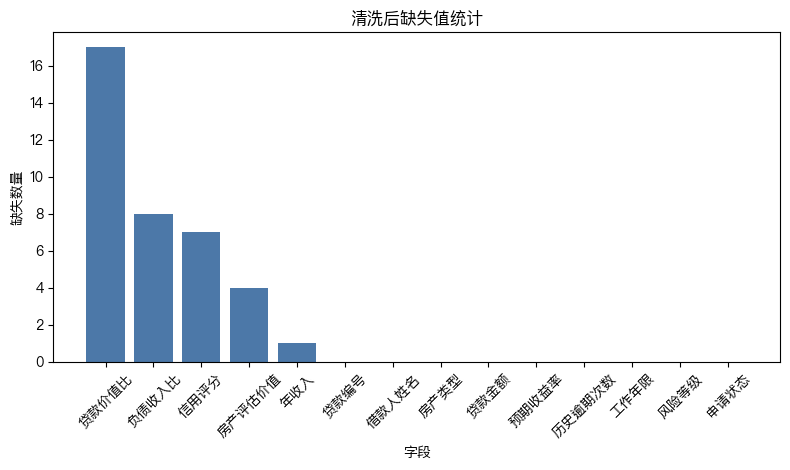

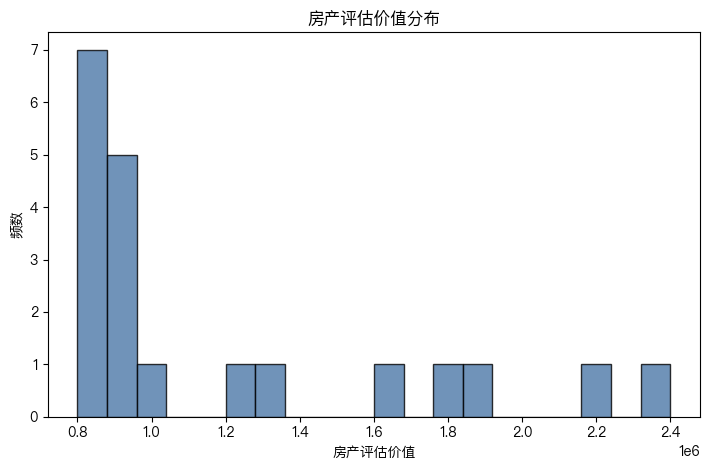

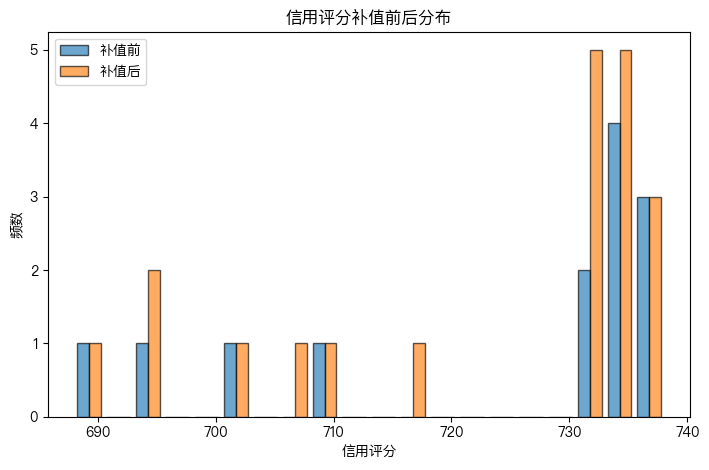

In [12]:
if result is not None:
    plot_core_views(result)
